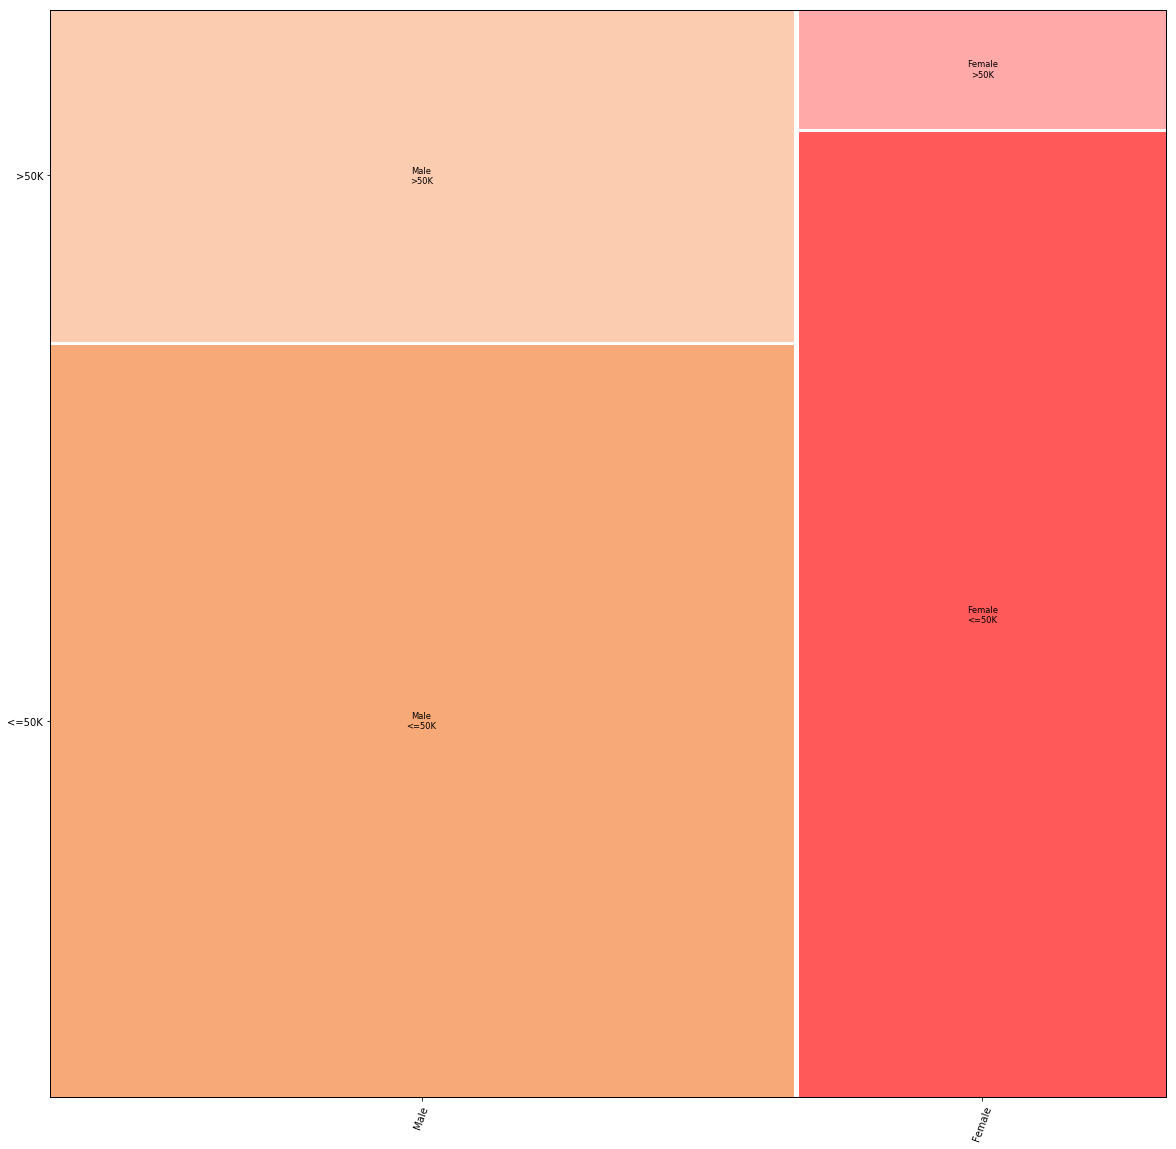

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

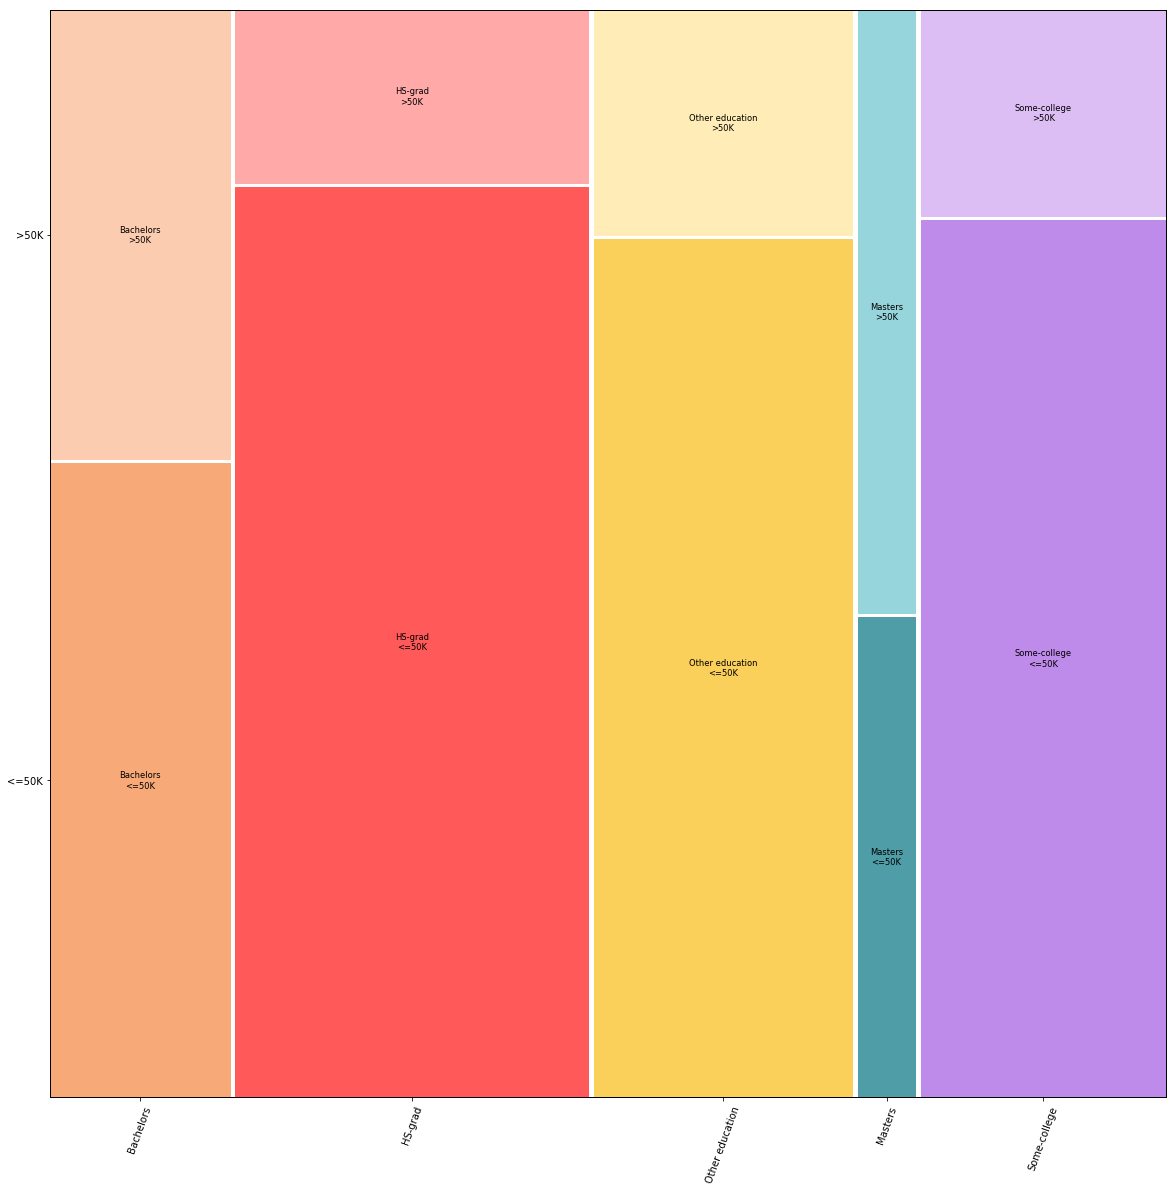

<Figure size 1440x1440 with 0 Axes>

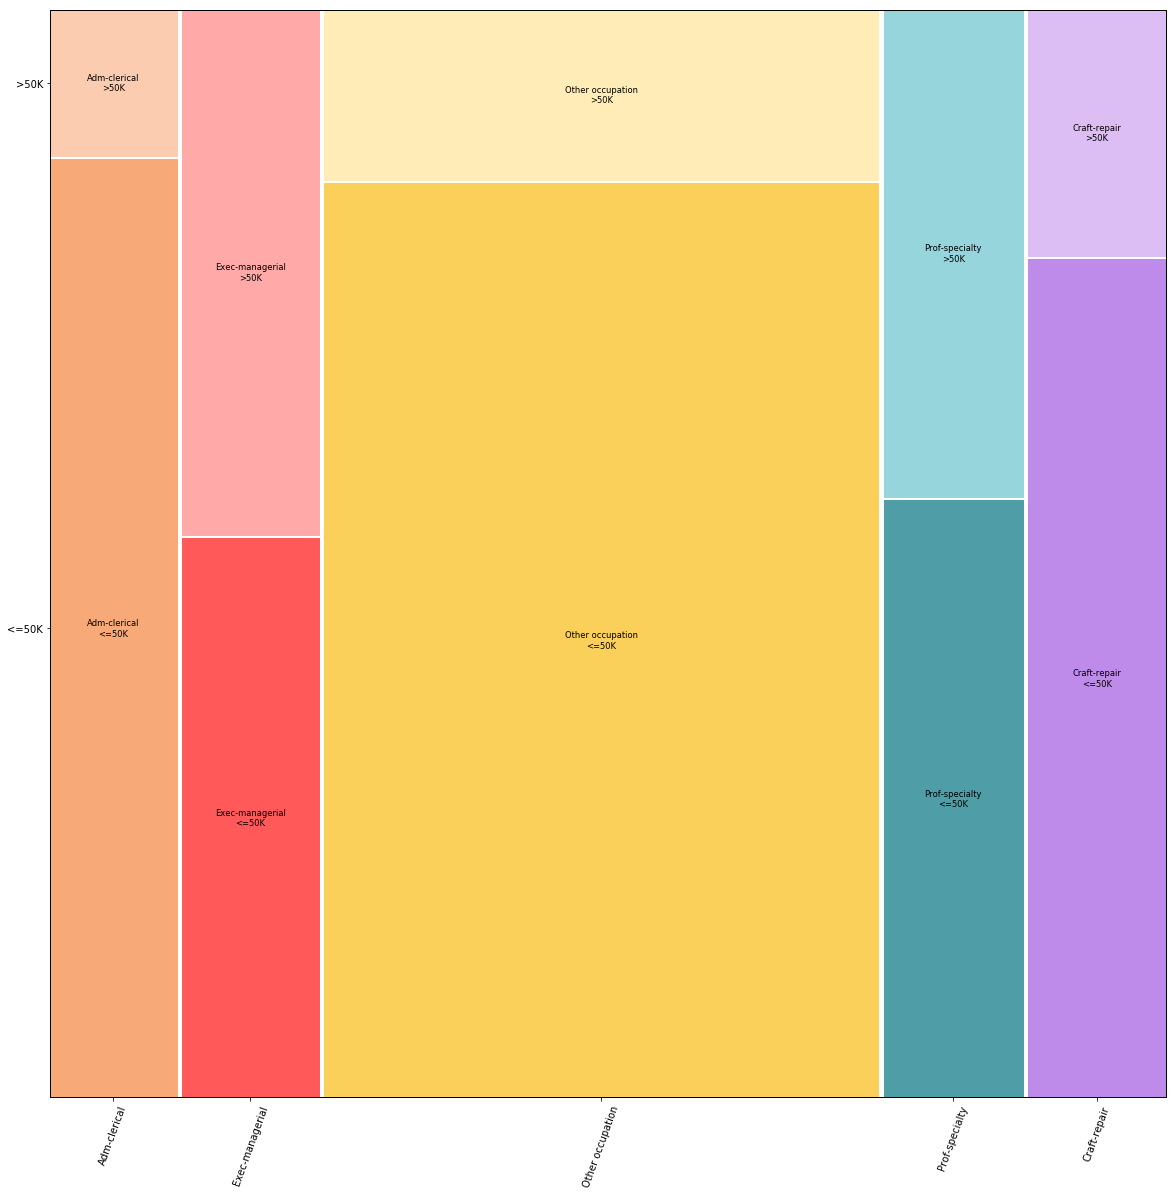

<Figure size 1440x1440 with 0 Axes>

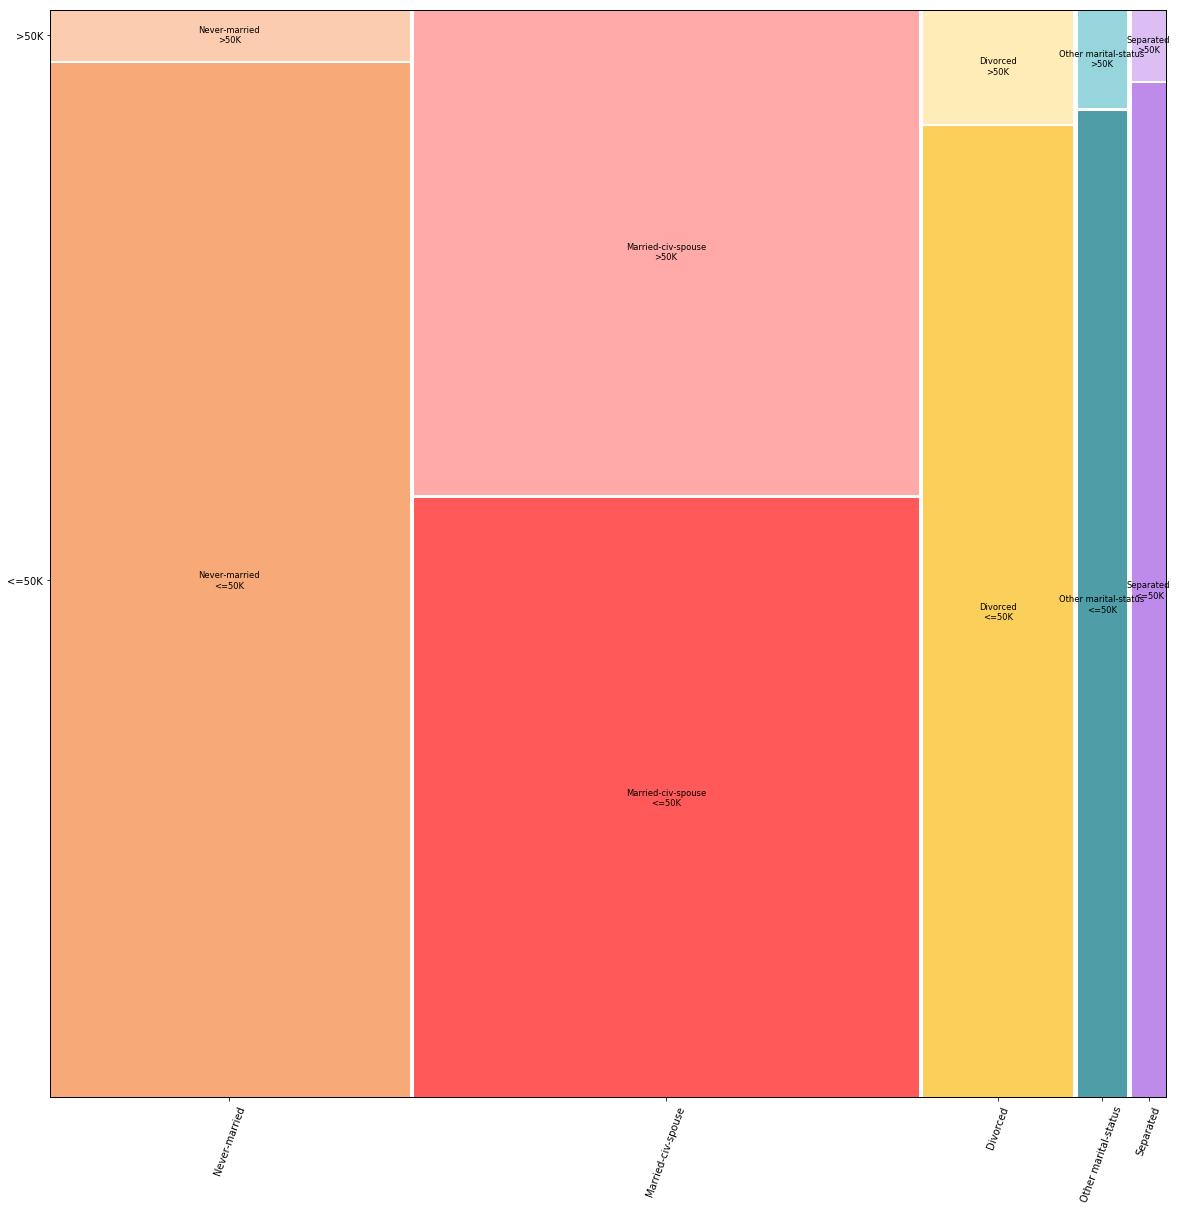

In [69]:
import matplotlib.pyplot as plt
import sqlite3 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt
import pandas

columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]
df = pd.read_csv("adult.data.txt", header=None, delimiter=', ', engine='python', names=columns);

comparisons = [
    ["sex", "income"],
    ["education", "income"],
    ["occupation", "income"],
    ["marital-status", "income"]
]

replacers = {}
for column in ["sex", "race", "education", "occupation", "marital-status", "native-country"]:
    counts = df[column].value_counts()
    i = 0
    replacers[column] = {}
    for key in counts.keys():
        if i < 4:
            replacers[column][key] = key
        else:
            replacers[column][key] = "Other " + column
        
        i = i + 1

for key in replacers:
    df[key].replace(to_replace=replacers[key], inplace=True)

colors = ['#f8a978', '#fbccaf', '#ff5959', '#ffa9a9', '#facf5a', '#ffecb7', '#4f9da6', '#96d5dc', '#bf8bea', '#dcbef5']

class Col:
    i = 0
    def colorProps(self, key):        
        col = colors[self.i]
        self.i = self.i+1
        return {'color': col}


for row in comparisons:
    col = Col()
    currentColorIndex = 0
    current = current + 1
    plt.figure(current)
    plt.rcParams['figure.figsize'] = [20, 20]
    
    mosaic(df, row, label_rotation=(70, 0), properties=col.colorProps)
    plt.xticks(rotation='vertical')
    plt.show()
